**Grupo 7:**

André Luiz Queiroz Valpassos

Luis Ernani Viniski

Lucas Barbosa dos Santos

Gabriel Bezerra Carrazzoni

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

## Obtendo os dados

In [4]:
df = pd.read_csv('https://raw.githubusercontent.com/selva86/datasets/master/BostonHousing.csv')

In [5]:
df.head()

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,b,lstat,medv
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,5.33,36.2


In [6]:
df.drop(columns=['b'], inplace=True)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 13 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   crim     506 non-null    float64
 1   zn       506 non-null    float64
 2   indus    506 non-null    float64
 3   chas     506 non-null    int64  
 4   nox      506 non-null    float64
 5   rm       506 non-null    float64
 6   age      506 non-null    float64
 7   dis      506 non-null    float64
 8   rad      506 non-null    int64  
 9   tax      506 non-null    int64  
 10  ptratio  506 non-null    float64
 11  lstat    506 non-null    float64
 12  medv     506 non-null    float64
dtypes: float64(10), int64(3)
memory usage: 51.5 KB


## Estatística Descritiva

In [8]:
df.describe()

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,lstat,medv
count,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000
mean,3.613524,11.363636,11.136779,0.069170,0.554695,6.284634,68.574901,3.795043,9.549407,408.237154,18.455534,12.653063,22.532806
std,8.601545,23.322453,6.860353,0.253994,0.115878,0.702617,28.148861,2.105710,8.707259,168.537116,2.164946,7.141062,9.197104
min,0.006320,0.000000,0.460000,0.000000,0.385000,3.561000,2.900000,1.129600,1.000000,187.000000,12.600000,1.730000,5.000000
25%,0.082045,0.000000,5.190000,0.000000,0.449000,5.885500,45.025000,2.100175,4.000000,279.000000,17.400000,6.950000,17.025000
50%,0.256510,0.000000,9.690000,0.000000,0.538000,6.208500,77.500000,3.207450,5.000000,330.000000,19.050000,11.360000,21.200000
75%,3.677083,12.500000,18.100000,0.000000,0.624000,6.623500,94.075000,5.188425,24.000000,666.000000,20.200000,16.955000,25.000000
max,88.976200,100.000000,27.740000,1.000000,0.871000,8.780000,100.000000,12.126500,24.000000,711.000000,22.000000,37.970000,50.000000


In [9]:
import missingno as msno

<Axes: >

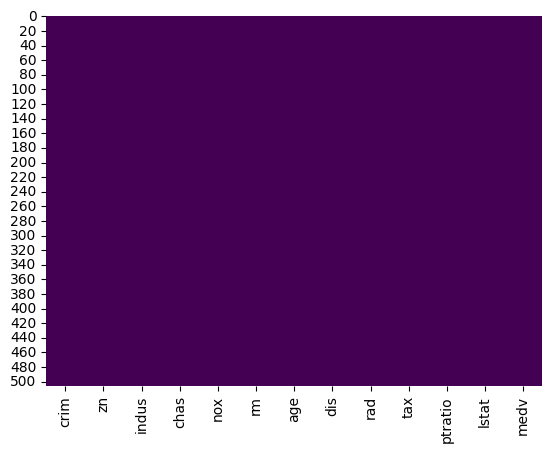

In [10]:
sns.heatmap(df.isnull(), cbar=False, cmap='viridis')

<Axes: >

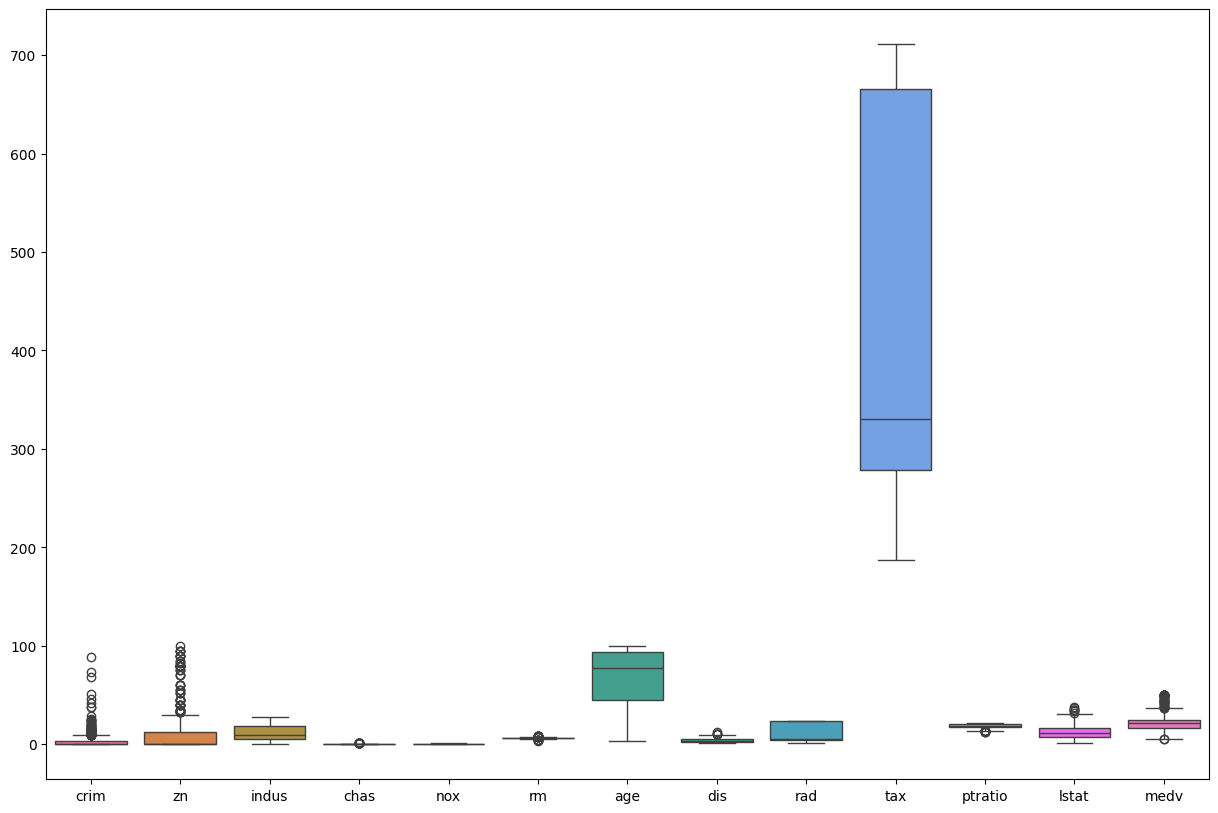

In [11]:
plt.figure(figsize = (15, 10))
sns.boxplot(data=df)

## Separação dos dados, holdout

In [12]:
from sklearn.model_selection import train_test_split

In [13]:
X_train, X_test, y_train, y_test = train_test_split(df.drop(columns=['medv']),
                                                    df['medv'],
                                                    test_size=0.3,
                                                    random_state=111)

In [14]:
pd.DataFrame(X_train).head(5)

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,lstat
199,0.03150,95.0,1.47,0,0.403,6.975,15.3,7.6534,3,402,17.0,4.56
101,0.11432,0.0,8.56,0,0.520,6.781,71.3,2.8561,5,384,20.9,7.67
386,24.39380,0.0,18.10,0,0.700,4.652,100.0,1.4672,24,666,20.2,28.28
77,0.08707,0.0,12.83,0,0.437,6.140,45.8,4.0905,5,398,18.7,10.27
176,0.07022,0.0,4.05,0,0.510,6.020,47.2,3.5549,5,296,16.6,10.11


## Normalização dos dados

In [15]:
from sklearn.preprocessing import StandardScaler

In [16]:
scaler = StandardScaler()

In [17]:
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [18]:
X_train_scaled[:3]

array([[-0.44907456,  3.78381385, -1.43347391, -0.28154625, -1.33889353,
         1.02600682, -1.97141772,  1.85891086, -0.76927921, -0.07524679,
        -0.75662273, -1.19006285],
       [-0.43799762, -0.46194571, -0.40276632, -0.28154625, -0.31222266,
         0.73462462,  0.06573687, -0.42852307, -0.54062695, -0.18141874,
         1.10972235, -0.74008473],
       [ 2.80931263, -0.46194571,  0.98410962, -0.28154625,  1.26727098,
        -2.46306977,  1.10977861, -1.09077412,  1.63156951,  1.48194185,
         0.77473734,  2.24192461]])

In [19]:
X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=X_train.columns, index=X_train.index)
X_train_scaled_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 354 entries, 199 to 340
Data columns (total 12 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   crim     354 non-null    float64
 1   zn       354 non-null    float64
 2   indus    354 non-null    float64
 3   chas     354 non-null    float64
 4   nox      354 non-null    float64
 5   rm       354 non-null    float64
 6   age      354 non-null    float64
 7   dis      354 non-null    float64
 8   rad      354 non-null    float64
 9   tax      354 non-null    float64
 10  ptratio  354 non-null    float64
 11  lstat    354 non-null    float64
dtypes: float64(12)
memory usage: 36.0 KB


In [20]:
X_test_scaled_df = pd.DataFrame(X_test_scaled, columns=X_test.columns, index=X_test.index)
X_test_scaled_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 152 entries, 93 to 158
Data columns (total 12 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   crim     152 non-null    float64
 1   zn       152 non-null    float64
 2   indus    152 non-null    float64
 3   chas     152 non-null    float64
 4   nox      152 non-null    float64
 5   rm       152 non-null    float64
 6   age      152 non-null    float64
 7   dis      152 non-null    float64
 8   rad      152 non-null    float64
 9   tax      152 non-null    float64
 10  ptratio  152 non-null    float64
 11  lstat    152 non-null    float64
dtypes: float64(12)
memory usage: 15.4 KB


## Regressão Linear

In [21]:
from sklearn.linear_model import LinearRegression

In [22]:
modelo = LinearRegression()
modelo.fit(X_train_scaled, y_train)

LinearRegression()

In [23]:
y_train_pred = modelo.predict(X_train_scaled)
y_test_pred = modelo.predict(X_test_scaled)

In [24]:
from sklearn.metrics import r2_score

In [25]:
r2_train = r2_score(y_train, y_train_pred)
r2_train

0.7381975510401046

In [26]:
r2_test = r2_score(y_test, y_test_pred)
r2_test

0.711547915567693

In [27]:
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error, mean_squared_error

In [28]:
def print_metrics(y_test_in, y_test_pred_in):
  print("MEAN: ", mean_absolute_error(y_test_in, y_test_pred_in))
  print("MAPE: ", mean_absolute_percentage_error(y_test_in, y_test_pred_in))
  print("MSE: ", mean_squared_error(y_test_in, y_test_pred_in))
  print("RMSE: ", mean_squared_error(y_test_in, y_test_pred_in)**2)
  print("R²: ", r2_score(y_test_in, y_test_pred_in))

In [29]:
print_metrics(y_train, y_train_pred)

MEAN:  3.1835585717761252
MAPE:  0.16078737073033178
MSE:  20.374619886830068
RMSE:  415.12513553281127
R²:  0.7381975510401046


In [30]:
print_metrics(y_test, y_test_pred)

MEAN:  3.701488287606292
MAPE:  0.17831885665559696
MSE:  28.607656840343854
RMSE:  818.3980298948725
R²:  0.711547915567693


## k-NN Regressão

In [33]:
from sklearn.neighbors import KNeighborsRegressor
knn = KNeighborsRegressor(n_neighbors=3)

In [34]:
knn.fit(X_train_scaled, y_train)

KNeighborsRegressor(n_neighbors=3)

In [35]:
y_pred = knn.predict(X_train_scaled)

In [38]:
r2_train = r2_score(y_train, y_pred)
r2_train

0.8670591164466853

In [39]:
knn.score(X_test_scaled, y_test)

0.7597083113180875

### Buscando o melhor K

k= 1
k= 2
k= 3
k= 4
k= 5
k= 6
k= 7
k= 8
k= 9
k= 10
k= 11
k= 12
k= 13
k= 14
k= 15
k= 16
k= 17
k= 18
k= 19
k= 20
k= 21
k= 22
k= 23
k= 24
k= 25
k= 26
k= 27
k= 28
k= 29


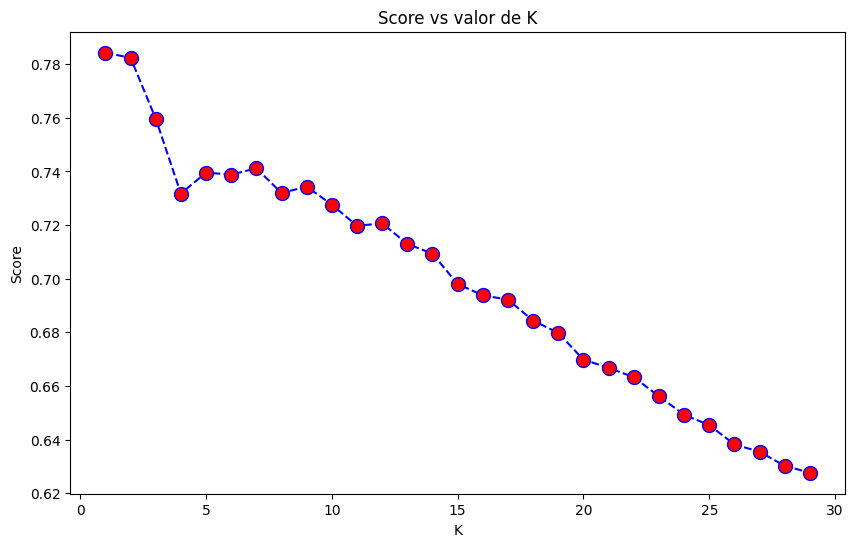

In [46]:
import numpy as np

score = []

for i in range(1,30):
  knn = KNeighborsRegressor(n_neighbors=i)
  knn.fit(X_train_scaled, y_train)
  y_pred = knn.predict(X_test_scaled)
  r2 = r2_score(y_test, y_pred)
  score.append(r2)
  print("k=", i)

plt.figure(figsize=(10,6))
plt.plot(range(1,30), score, color='blue', linestyle='dashed', marker='o',
           markerfacecolor = 'red', markersize=10)
plt.title('Score vs valor de K')
plt.xlabel('K')
plt.ylabel('Score')
plt.show()

### Com o melhor k=1

In [52]:
knn = KNeighborsRegressor(n_neighbors=1)
knn.fit(X_train_scaled, y_train)
print(knn.score(X_train_scaled, y_train))
print(knn.score(X_test_scaled, y_test))

1.0
0.7842753969841532


In [54]:
y_pred = knn.predict(X_train_scaled)
print_metrics(y_train, y_pred)

MEAN:  0.0
MAPE:  0.0
MSE:  0.0
RMSE:  0.0
R²:  1.0


In [55]:
y_pred = knn.predict(X_test_scaled)
print_metrics(y_test, y_pred)

MEAN:  3.132236842105263
MAPE:  0.15442199439994692
MSE:  21.394802631578948
RMSE:  457.7375796442175
R²:  0.7842753969841532


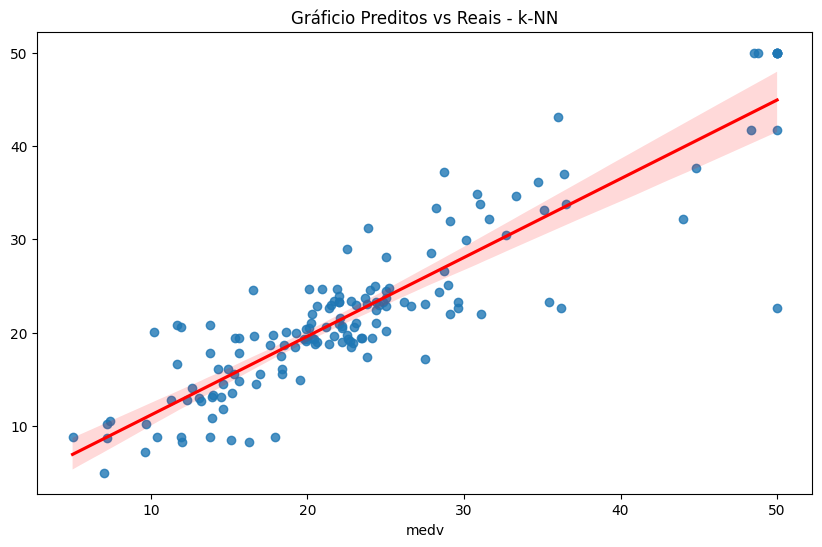

In [66]:
plt.figure(figsize=(10,6))
plt.title('Gráficio Preditos vs Reais - k-NN')
sns.regplot(x=y_test,y=y_pred,line_kws={"color": "red"})
plt.show()

## Modelo de Regressão Polinomial com n=1, n=5, n=10

In [67]:
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures

In [68]:
poly_grau_1 = PolynomialFeatures(degree=1)
X_train_scaled_poly_1 = poly_grau_1.fit_transform(X_train_scaled)
X_test_scaled_poly_1 = poly_grau_1.transform(X_test_scaled)

In [69]:
poly_grau_5 = PolynomialFeatures(degree=5)
X_train_scaled_poly_5 = poly_grau_5.fit_transform(X_train_scaled)
X_test_scaled_poly_5 = poly_grau_5.transform(X_test_scaled)

In [70]:
poly_grau_10 = PolynomialFeatures(degree=10)
X_train_scaled_poly_10 = poly_grau_10.fit_transform(X_train_scaled)
X_test_scaled_poly_10 = poly_grau_10.transform(X_test_scaled)

### n = 1

In [61]:
modelo.fit(X_train_scaled_poly_1, y_train)

LinearRegression()

In [71]:
y_train_pred_poly1 = modelo.predict(X_train_scaled_poly_1)
y_test_pred_poly1 = modelo.predict(X_test_scaled_poly_1)

In [72]:
print_metrics(y_test, y_test_pred_poly1)

MEAN:  3.7014882876062947
MAPE:  0.17831885665559713
MSE:  28.60765684034387
RMSE:  818.3980298948735
R²:  0.7115479155676928


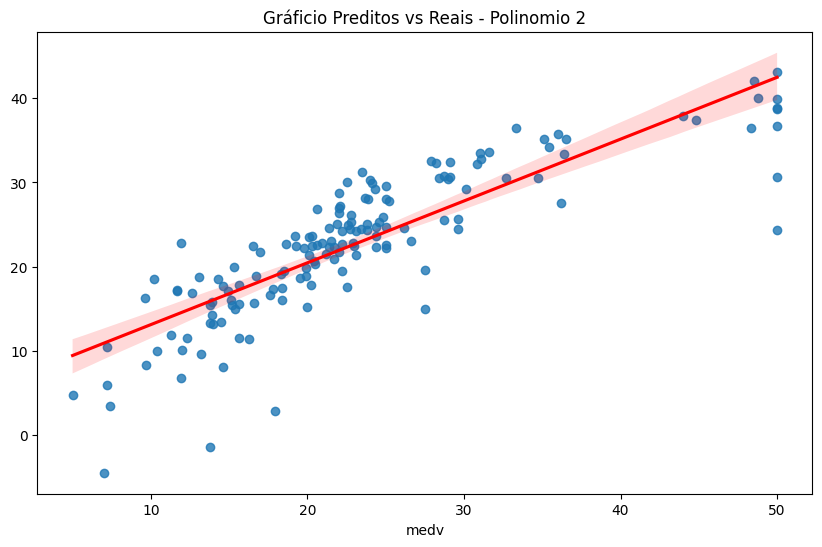

In [73]:
plt.figure(figsize=(10,6))
plt.title('Gráficio Preditos vs Reais - Polinomio 2')
sns.regplot(x=y_test,y=y_test_pred_poly1,line_kws={"color": "red"})
plt.show()

### n = 5

In [74]:
modelo.fit(X_train_scaled_poly_5, y_train)

LinearRegression()

In [75]:
y_train_pred_poly5 = modelo.predict(X_train_scaled_poly_5)
y_test_pred_poly5 = modelo.predict(X_test_scaled_poly_5)

In [76]:
print_metrics(y_test, y_test_pred_poly5)

MEAN:  111.86301225380016
MAPE:  10.490816949029721
MSE:  1107844.0243524152
RMSE:  1227318382293.3547
R²:  -11169.433140811145


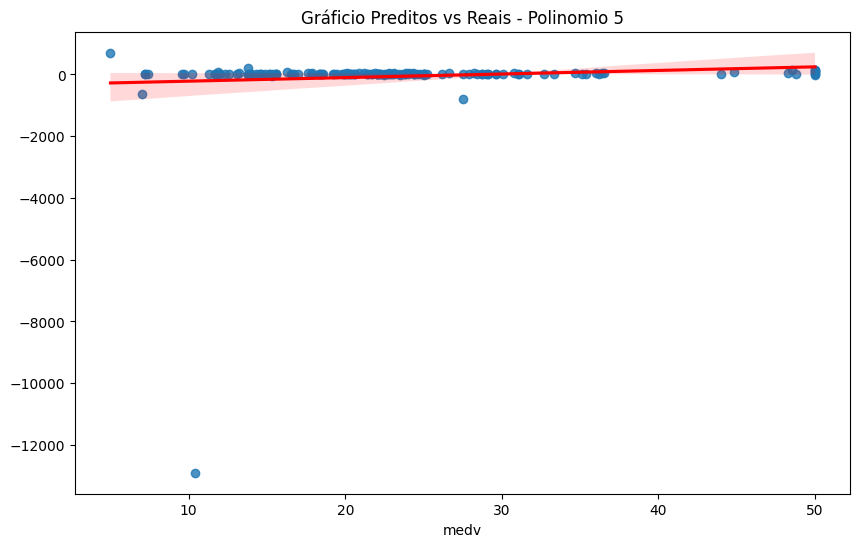

In [82]:
plt.figure(figsize=(10,6))
plt.title('Gráficio Preditos vs Reais - Polinomio 5')
sns.regplot(x=y_test,y=y_test_pred_poly5,line_kws={"color": "red"})
plt.show()

### n = 10

In [78]:
modelo.fit(X_train_scaled_poly_10, y_train)

LinearRegression()

In [79]:
y_train_pred_poly10 = modelo.predict(X_train_scaled_poly_10)
y_test_pred_poly10 = modelo.predict(X_test_scaled_poly_10)

In [83]:
print_metrics(y_test, y_test_pred_poly10)

MEAN:  61310.04590145789
MAPE:  6040.642511353901
MSE:  534457910567.2245
RMSE:  2.8564525816788334e+23
R²:  -5388959297.723132


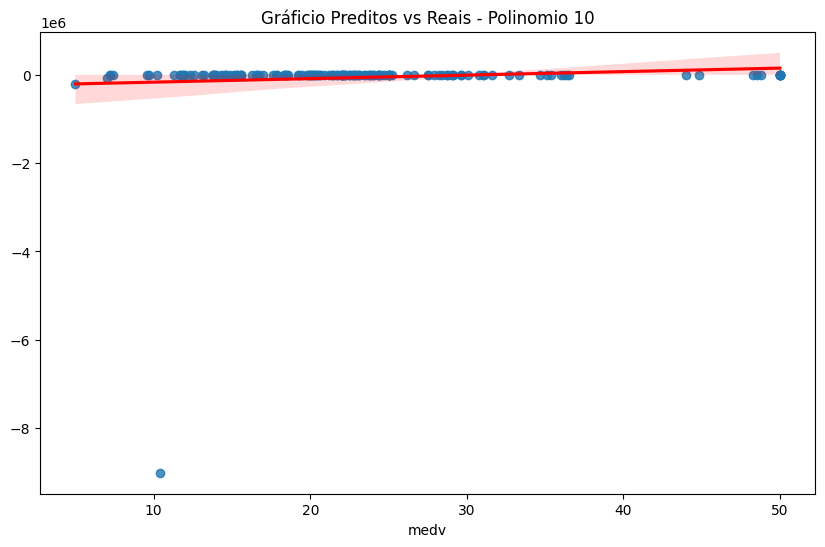

In [81]:
plt.figure(figsize=(10,6))
plt.title('Gráficio Preditos vs Reais - Polinomio 10')
sns.regplot(x=y_test,y=y_test_pred_poly10,line_kws={"color": "red"})
plt.show()

## **Conclusão**

1. Regressão Linear:

A regressão linear apresentou resultados consistentes:
R² = 0.7115 indica que cerca de 71% da variação nos preços das casas foi explicada pelo modelo.

Os erros foram razoavelmente baixos (MAE = 3.70, MAPE ≈ 17.8%, RMSE = 818.4), indicando um bom ajuste geral.

2. Regressão com KNN (melhor k = 1):

O modelo baseado em KNN apresentou desempenho superior à regressão linear:

R² = 0.7843, sugerindo um poder preditivo maior.

Também obteve menores valores de erro (MAE = 3.13, MAPE ≈ 15.4%, MSE = 21.39), demonstrando uma melhor capacidade de previsão e menor sensibilidade a outliers.

O RMSE (≈ 457.7) foi significativamente menor que o da regressão linear, reforçando sua superioridade neste caso.


3. Regressão Polinomial:

A regressão polinomial foi testada com graus n = 1, n = 5 e n = 10

Para n=1, o modelo é matematicamente equivalente à regressão linear, portanto os resultados são idênticos.

Para n=5 e n=10, o modelo apresentou sinais claros de overfitting extremo. As métricas de erro cresceram exponencialmente:

R² negativo e muito distante de zero (ex: -11169 e -5.39e+09), indicando que o modelo está pior que uma linha horizontal no ajuste dos dados.

Erros absurdamente altos (MAE > 100 mil, MAPE > 1000%, RMSE em escala de bilhões e trilhões), o que comprova que o modelo não generaliza bem.

Esse comportamento é típico em modelos polinomiais de grau alto, que se ajustam demais aos dados de treino e falham ao prever dados novos (teste).

Dentre todos os modelos testados, o KNN com o melhor valor de K se destacou como o mais eficaz, apresentando o menor erro e o maior R² entre os modelos. Ele conseguiu equilibrar bem o viés e a variância, sendo mais robusto na previsão dos dados de teste.

A regressão linear também teve desempenho aceitável e estável, sendo uma boa opção para interpretações mais simples. Já a regressão polinomial com graus mais altos apresentou sérios problemas de generalização, sendo inadequada nesse contexto.

Portanto, com base nas métricas e nos resultados obtidos, o modelo KNN Regressor se mostrou a melhor escolha para esse problema de previsão de preços de casas no conjunto de dados Boston Housing.